Метод Эйлера - один из базовых численных методов решения дифференциальных уравнений первого порядка. В контексте геофизики метод Эйлера часто используется для моделирования различных процессов, таких как движение частиц в гравитационном поле Земли, расчеты траекторий метеорологических объектов и другие задачи, где динамика системы описывается системой обыкновенных дифференциальных уравнений (ОДУ).
Алгоритм метода Эйлера

Пусть дано ОДУ вида:
$y’= f(t, y)$,
где у - искомая функция, зависящая от переменной t, a $f(t, y)$ - заданная функция.
Шаг метода Эйлера заключается в следующем приближении:

$y_{n+1} = y_n + h * f(t_m, y_n)$,
где h - шаг интегрирования, $t_n = t_o + n * h$.
Этот метод прост в реализации, однако имеет низкую точность, особенно при больших значениях шага һ.
Тем не менее, он часто служит отправной точкой для понимания более сложных методов.
    Уравнение Вольтерры-Лотки
Уравнение Вольтерры-Лотки описывает динамику популяций хищников и жертв. Оно представляет собой систему двух нелинейных дифференциальных уравнений:
\begin{cases}
  dN/dt= rN - aNP \\
  dP/dt= bNP - mP
\end{cases}

где:
N — численность популяции жертвы,
P — численность популяции хищника,
r,a,b,m — константы, определяющие скорость роста/убыли каждой популяции.
Применение метода Эйлера
Чтобы применить метод Эйлера для решения этой системы, нужно использовать итерационный процесс, где значения переменных обновляются на каждом временном шаге Δt
Шаги следующие:
1. Вычисление производной на основе текущих значений переменных N и Р.
Производная dN/dt
вычисляется как:
$dN/dt = rN_i - aN_iP_i$
Аналогично для P:
$dP/dt= bN_iP_i - mP_i$
2. Обновление значений на следующем шаге:
Новые значения $N_{i+1}$ и $Р_{і+1}$ находятся по
формулам:
$N_{i+1} = N_i + Δt * (rN_i - aN_iP_i)$
$P_{i+1} = P_i + Δt * (bN_iP_i - mP_i)$
3. Повторение процесса до достижения заданного конечного времени T.
Таким образом, используя этот алгоритм, мы можем пошагово находить приближенное решение системы уравнений Вольтерры-Лотки методом Эйлера.



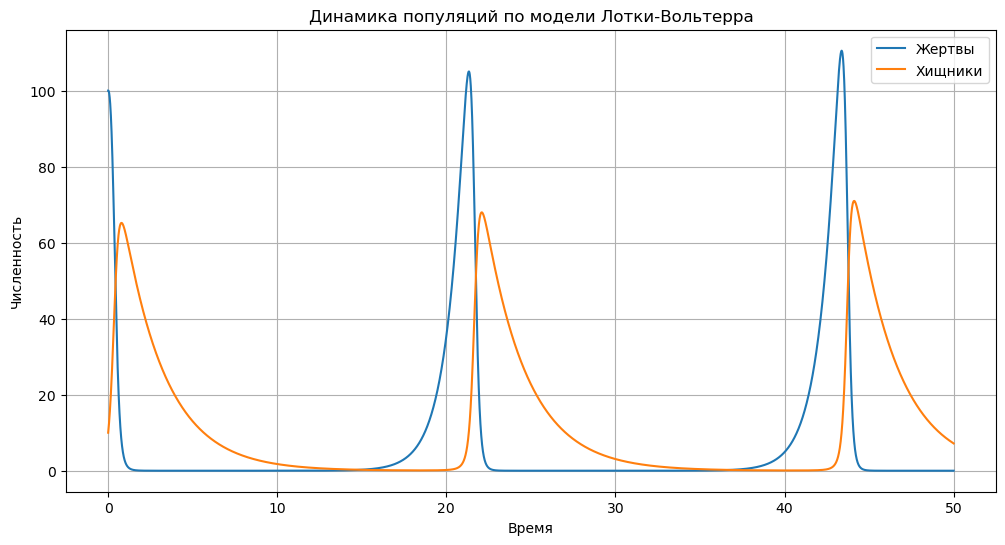

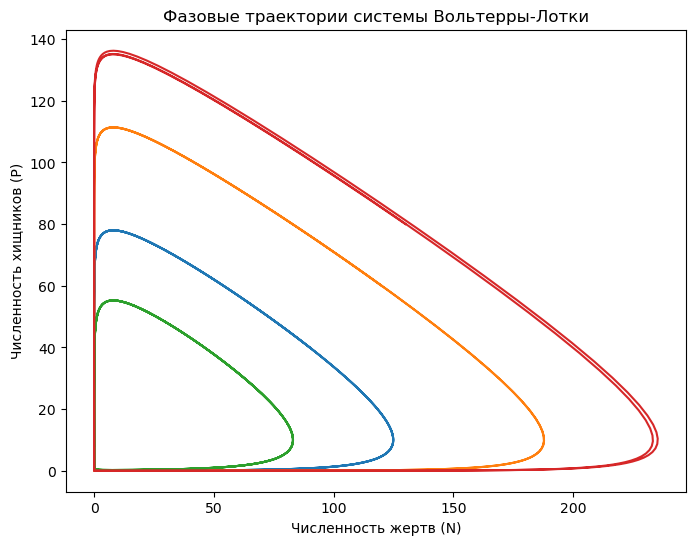

In [9]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Параметры модели
r = 1.0  # Скорость размножения жертв
a = 0.1  # Влияние хищников на жертву
b = 0.05 # Влияние жертв на хищников
m = 0.4  # Скорость вымирания хищников

# Начальные условия
N0 = 100  # Начальная численность жертв
P0 = 10   # Начальная численность хищников

# Временные параметры
t0 = 0     # Начальное время
T = 50    # Конечное время
dt = 0.01  # Шаг по времени

# Количество шагов
steps = int((T - t0) / dt)

# Массивы для хранения результатов
time = np.linspace(t0, T, steps)
N = np.zeros(steps)
P = np.zeros(steps)

# Начальные условия
N[0] = N0
P[0] = P0

# Метод Эйлера
for i in range(steps - 1):
    dN_dt = r * N[i] - a * N[i] * P[i]
    dP_dt = b * N[i] * P[i] - m * P[i]
    
    N[i+1] = N[i] + dt * dN_dt
    P[i+1] = P[i] + dt * dP_dt

# Построение графиков
plt.figure(figsize=(12, 6))
plt.plot(time, N, label='Жертвы')
plt.plot(time, P, label='Хищники')
plt.xlabel('Время')
plt.ylabel('Численность')
plt.title('Динамика популяций по модели Лотки-Вольтерра')
plt.legend()
plt.grid(True)
plt.show()

# Функция правых частей системы Вольтерры-Лотки
def volterra_lotka(state, t):
    N, P = state
    dNdt = r * N - a * N * P
    dPdt = b * N * P - m * P
    return [dNdt, dPdt]

# Время моделирования
t = np.linspace(20, 100, 5000)

# Различные начальные условия
initial_conditions = [
    [90, 40],  # Начальная точка 1
    [120, 60],  # Начальная точка 2
    [70, 25],   # Начальная точка 3
    [130, 80]   # Начальная точка 4
]

# Решение системы для каждого набора начальных условий
solutions = []
for ic in initial_conditions:
    sol = odeint(volterra_lotka, ic, t)
    solutions.append(sol)

# Построение фазовых траекторий
plt.figure(figsize=(8, 6))
for sol in solutions:
    plt.plot(sol[:, 0], sol[:, 1], '-')  # Построение траекторий в фазовом пространстве

# Обозначение осей
plt.xlabel("Численность жертв (N)")
plt.ylabel("Численность хищников (P)")
plt.title("Фазовые траектории системы Вольтерры-Лотки")

# Показать график
plt.show()
